### Simulating analysis of MID data

Russ Poldrack, Jeanette Mumford, and Michael Demidenko

Here we simulate various analysis strategies for the Monetary Incentive Delay (MID) task as used by the ABCD study.  The strategy is to use the actual designs for a group of real subjects (from a different study using a similar design, given the inability to share ABCD files openly).  We set up three models used in the literature, and then generate simulated data with signal for one component of the task and assess the ability of each model to detect this signal and to control error for other components of the model.

In [1]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
from poldracklab.fmri.spm_hrf import spm_hrf
import statsmodels.api as sm
import statsmodels.formula.api as smf

np.random.seed(1234)

####  Data loader

This loads event files from the AHRB study, which uses the same design as ABCD.

In [2]:
def get_subdata(sub, run, verbose=False):
    sub = str(sub).zfill(2)
    eventfile = f'https://raw.githubusercontent.com/poldrack/MID_simulations/main/AHRB/sub-{sub}/ses-1/func/sub-{sub}_ses-1_task-mid_run-0{run}_events.tsv'
    df = pd.read_csv(eventfile, sep='\t')
    if verbose:
        print(f'Loading {eventfile}')
        print(df.shape)
    assert df.shape[1] > 2, f'bad parsing'
    return df

# show an example
events = get_subdata(1, 1)
events.head()



,TRIAL_TYPE,CUE_ONSET,CUE_DURATION,FIXATION_ONSET,FIXATION_DURATION,PROBE_ONSET,PROBE_DURATION,FEEDBACK_ONSET,FEEDBACK_DURATION,TRIAL_RESULT,RESULT_REASON,PROBE_HIT,PROBE_MRT
0,NoMoneyStake,0.058,2,2.008,2.0,4.007,0.319,4.407,1.631,No money at stake!,You pressed too slow!,0,0
1,NoMoneyStake,6.024,2,8.007,1.5,9.506,0.319,9.906,1.631,No money at stake!,You pressed too slow!,0,0
2,LargeLoss,11.556,2,13.506,2.5,16.005,0.319,16.405,1.631,You keep $5!,Correct Response!,1,306
3,NoMoneyStake,18.022,2,20.005,1.5,21.504,0.319,21.904,1.631,No money at stake!,Correct Response!,1,318
4,LargeGain,23.554,2,25.504,1.5,27.004,0.319,27.403,1.631,You did not earn $5!,You pressed too slow!,0,0


#### Create stick function regressors

Create the regressors for each event; these are boxcar regressors that are defined as the actual duration of the event.

In [3]:
def get_trial_regressors(df, resolution=.1, padding=2):
    maxtime = np.round(df.iloc[-1, df.columns=='FEEDBACK_ONSET'][0] + 
                       df.iloc[-1, df.columns=='FEEDBACK_DURATION'][0] + padding).astype('int')
    
    sf = pd.DataFrame({'time': np.arange(0, maxtime + resolution, resolution)})
    for var in ['cue', 'fix', 'probe', 'fb']:
        sf[var] = 0
    
    all_event_times = []
    for trialnum in df.index:
        trial_df = df.iloc[trialnum, :]
        
        cue_offset = trial_df.CUE_ONSET + trial_df.CUE_DURATION
        fix_onset = trial_df.FIXATION_ONSET
        fix_offset = fix_onset  + trial_df.FIXATION_DURATION
        probe_onset = trial_df.PROBE_ONSET
        probe_offset = probe_onset + trial_df.PROBE_DURATION
        fb_onset = trial_df.FEEDBACK_ONSET
        fb_offset = fb_onset + trial_df.FEEDBACK_DURATION
        
        event_times = pd.Series({
            'cue_onset': trial_df.CUE_ONSET,
            'cue_offset': cue_offset,
            'fix_onset': fix_onset,
            'fix_offset': fix_offset,
            'probe_onset': probe_onset,
            'probe_offset': probe_offset,
            'fb_onset': fb_onset,
            'fb_offset': fb_offset})
        all_event_times.append(event_times)
        
        cue_idx = np.logical_and(sf.time.values >= event_times.cue_onset, sf.time.values <= event_times.cue_offset)
        sf.loc[cue_idx == True, 'cue'] = 1
        fix_idx = np.logical_and(sf.time.values >= event_times.fix_onset, sf.time.values <= event_times.fix_offset)
        sf.loc[fix_idx, 'fix'] = 1
        probe_idx = np.logical_and(sf.time.values >= event_times.probe_onset, sf.time.values <= event_times.probe_offset)
        sf.loc[probe_idx, 'probe'] = 1
        fb_idx = np.logical_and(sf.time.values >= event_times.fb_onset, sf.time.values <= event_times.fb_offset)
        sf.loc[fb_idx, 'fb'] = 1
    return(sf, all_event_times)

sf, all_event_times = get_trial_regressors(events)

### Plot for reality check

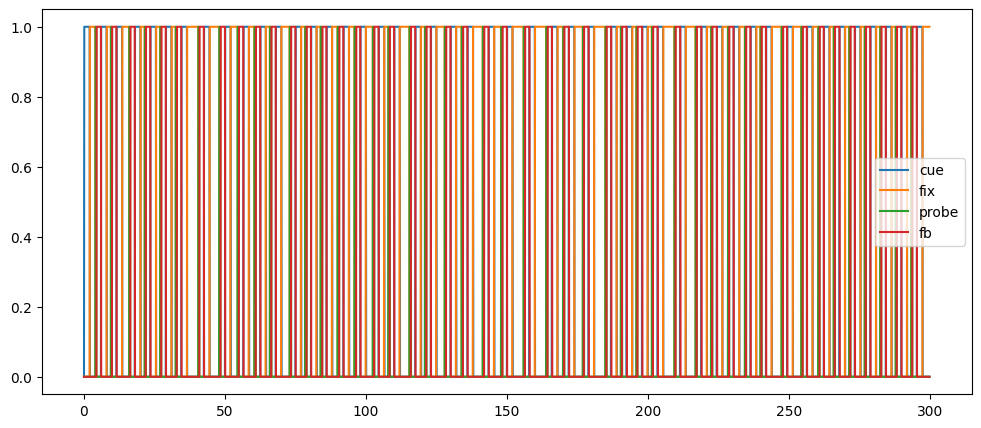

In [4]:
ntp = 3000
plt.figure(figsize=(12,5))
resolution=.1
plt.plot(sf.index[:ntp] * resolution, sf.cue[:ntp], label='cue')
plt.plot(sf.index[:ntp] * resolution, sf.fix[:ntp], label='fix')
plt.plot(sf.index[:ntp] * resolution, sf.probe[:ntp], label='probe')
plt.plot(sf.index[:ntp] * resolution, sf.fb[:ntp], label='fb')
plt.legend()

#### Create convolved regressors and models

We create three models, based on different models used in the literature (cf [Demidenko et al., 2024](https://www.biorxiv.org/content/10.1101/2024.03.19.585755v1)). In addition to modeling the feedback event, these models include a regressor modeling the following:

1. onset = Cue Onset, duration = Cue Duration
2. onset = Cue Onset, duration = Cue + Fixation Duration
3. onset = Fixation onset, duration = Fixation Duration




In [5]:
def convolve_regressors(sf, resolution=.1):
    sf_conv = pd.DataFrame(np.zeros(sf.shape), columns=sf.columns)
    for col in sf.columns:
        if col == 'time':
            sf_conv[col] = sf[col]
            continue
        sf_conv[col] = np.convolve(sf[col].values, 
                                spm_hrf(resolution))[:sf_conv.shape[0]]
    sf_conv = sf_conv.set_index('time')
    return sf_conv

sf_conv = convolve_regressors(sf)

# create the three models
def create_models(sf):
    # 1. MID: Cue Onset, Cue Duration only 
    model1 = sf.copy()
    model1['task'] = model1.cue
    model1 = model1[['time', 'task', 'fb']]

    # 2. MID: Cue Onset, Cue + Fixation Duration
    model2 = sf.copy()
    model2['task'] = np.clip(model2.cue + model2.fix, 0, 1)
    model2 = model2[['time', 'task', 'fb']]

    # 3. MID: Fixation onset, Fixation Duration
    model3 = sf.copy()
    model3['task'] = model3.fix
    model3 = model3[['time', 'task', 'fb']]
    return {'CueOnly': model1, 'CueFix': model2, 'FixOnly': model3}

models = create_models(sf)
models_conv = {key: convolve_regressors(value) for key, value in models.items()}

#### Plot for reality check

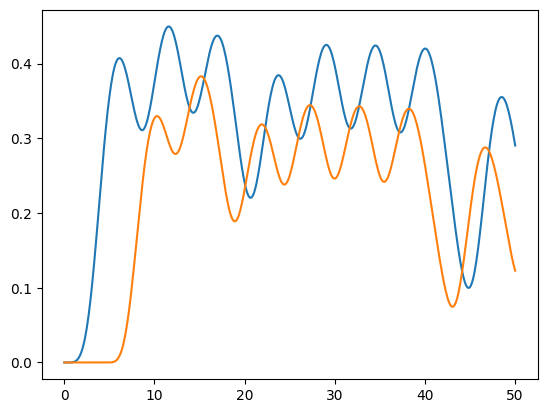

In [6]:
plt.plot(models_conv['CueOnly'].task[:50])
plt.plot(models_conv['CueOnly'].fb[:50])

#### Generate data

Create a function to generate simulated data by multiplying the design matrix by the relevant betas, and adding noise. Currently we add independent Gaussian noise; this is a not realistic for fMRI data, but in our experience it should not affect the results of a simulation like this one.

In [7]:

def generate_data(conv_df, betas, mean=100, noise_sd=1, seed=None):
    rng = np.random.default_rng(seed)
    
    return conv_df.values.dot(betas) + mean + rng.normal(scale=noise_sd, size=conv_df.shape[0])
    
betas = np.array([1, 0, 0, 0])

data = generate_data(sf_conv, betas)

#### Run models

Set up functions to estimate each of the models for the given dataset, and to extract coefficients from the statsmodels OLS output.

In [8]:
def get_coefficients_pvalues(ols_result):
    coef = ols_result.params
    pvals = ols_result.pvalues
    results = pd.DataFrame({'coef': coef, 'pvals': pvals})
    results.drop('const', inplace=True)
    return results

def run_models(models, data):
    model_results = None

    for key, value in models.items():
        ols_result = sm.OLS(data, sm.add_constant(value)).fit()
        result = get_coefficients_pvalues(ols_result).reset_index()
        result['model'] = key
        if model_results is None:
            model_results = result
        else:
            model_results = pd.concat([model_results, result])
        model_results.reset_index(drop=True, inplace=True)
    return model_results

model_results = run_models(models_conv, data)
model_results

,index,coef,pvals,model
0,task,0.884645,0.000083,CueOnly
1,fb,-0.061497,0.803730,CueOnly
2,task,-0.084431,0.622415,CueFix
3,fb,0.265742,0.272418,CueFix
4,task,-0.501338,0.001653,FixOnly
5,fb,-0.126684,0.635392,FixOnly


### Run each model for all subjects/models

NOTE: The effect sizes for the injected signals differ between the simulations. They were tuned by hand to try to get maximum power in the ~0.9 range, so that the range was more easily visible. 

TODO:

- generate power curves across a range of deltas

#### 0: null baseline

In [9]:
all_results = {}


def run_simulation(betas, run=1, nsims=100, threshold=0.05, noise_sd=1.0, resolution=.1):
    all_results = None
    for sub in np.arange(1, 109):
        try:
            events = get_subdata(sub, run)
        except:
            print(f'Error loading sub {sub}')
            continue
        sf, all_event_times = get_trial_regressors(events, resolution)
        sf_conv = convolve_regressors(sf)
        models = create_models(sf)
        models_conv = {key: convolve_regressors(value) for key, value in models.items()}
        for sim in range(nsims):
            data = generate_data(sf_conv, betas, noise_sd=noise_sd)
            model_results = run_models(models_conv, data)
            model_results['sub'] = sub
            model_results['run'] = run
            if len(np.where(betas)[0]) > 0:
                model_results['true_signal'] = np.where(betas)[0][0]
            else:
                model_results['true_signal'] = -1
            if all_results is None:
                all_results = model_results
            else:
                all_results = pd.concat([all_results, model_results])
    all_results['sigp'] = all_results['pvals'] < threshold
    return all_results

betas = np.array([0, 0, 0, 0])
all_results['null'] = run_simulation(betas)    

Error loading sub 5


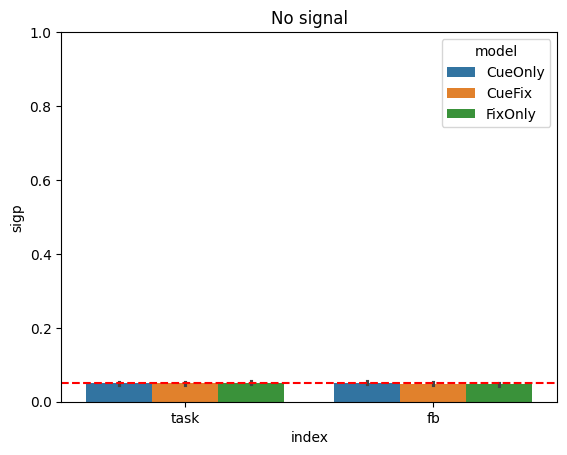

In [10]:
sns.barplot(data=all_results['null'], x='index', y='sigp', hue='model')
plt.title('No signal')
plt.ylim(0,1)
plt.axhline(0.05, color='red', linestyle='--')

Summary: This is just a reality check to make sure that error is appropriate when no signal is injected.


#### 1: True effect of cue only

In [11]:
delta = 0.8 # effect size
betas = np.array([delta, 0, 0, 0])
all_results['Cue'] = run_simulation(betas)    

Error loading sub 5


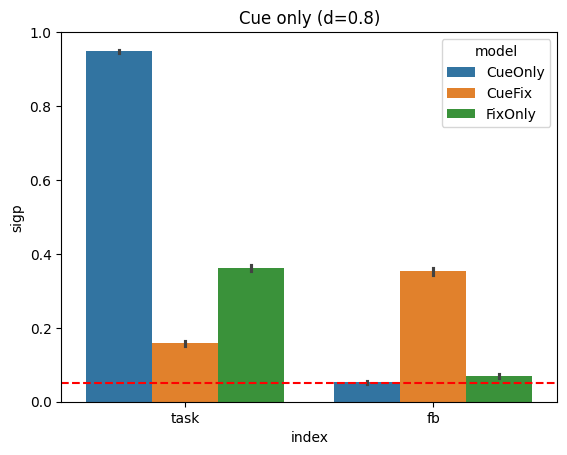

In [12]:
sns.barplot(data=all_results['Cue'], x='index', y='sigp', hue='model')
plt.title(f'Cue only (d={delta})')
plt.ylim(0,1)
plt.axhline(0.05, color='red', linestyle='--')

Summary: When there is only cue activity, the (correct) CueOnly model shows much higher detection than the other models, with some degree of error for the FixOnly model.  For the CueFix model there is inflated error for the feedback regressor.


#### 2: True effect of fixation only

In [13]:
delta = 0.6 # effect size
betas = np.array([0, delta, 0, 0])
all_results['Fix'] = run_simulation(betas)

Error loading sub 5


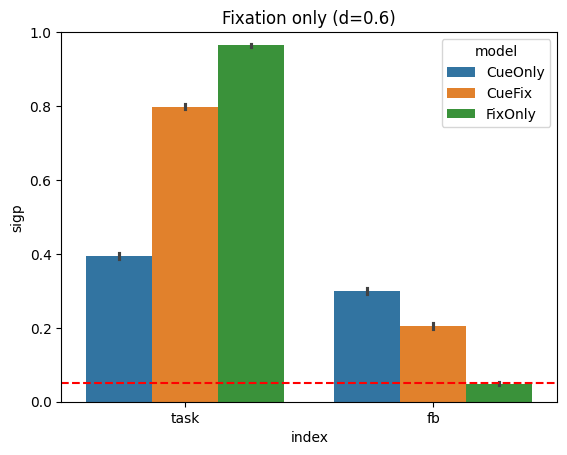

In [14]:
sns.barplot(data=all_results['Fix'], x='index', y='sigp', hue='model')
plt.title(f'Fixation only (d={delta})')
plt.ylim(0,1)
plt.axhline(0.05, color='red', linestyle='--')

Summary: When there is fixation activation only, the (correct) FixOnly model shows the highest level of detection, with relatively high detection for CueFix and some degree of error for CueOnly.  The CueOnly and CueFix models show inflated error for the feedback regressor.

#### 3: True effect of probe only

In [15]:
delta = 1
betas = np.array([0, 0, delta, 0])
all_results['Probe'] = run_simulation(betas) 

Error loading sub 5


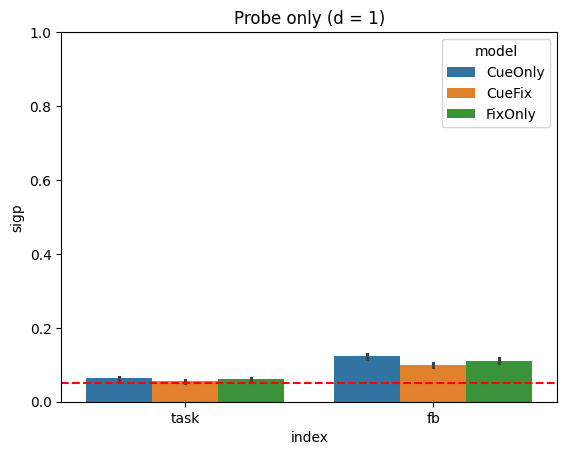

In [16]:
sns.barplot(data=all_results['Probe'], x='index', y='sigp', hue='model')
plt.title(f'Probe only (d = {delta})')
plt.ylim(0,1)
plt.axhline(0.05, color='red', linestyle='--')

Summary: When there is very strong unmodeled probe activity, it results in slightly inflated error rates for all models for the feedback regressor.

#### 4: True efffect of feedback only

In [17]:
delta = 0.8
betas = np.array([0, 0, 0, delta])
all_results['Fb'] = run_simulation(betas)   

Error loading sub 5


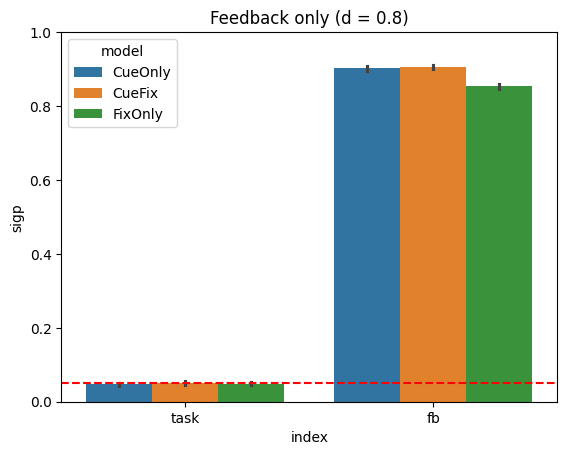

In [18]:
sns.barplot(data=all_results['Fb'], x='index', y='sigp', hue='model')
plt.title(f'Feedback only (d = {delta})')
plt.ylim(0,1)
plt.axhline(0.05, color='red', linestyle='--')

All models show expected behavior, detecting the feedback signal and controlling error for the task regressor.

#### 5: True effect of both cue and fixation

In [19]:
delta = 0.5
betas = np.array([delta, delta, 0, 0])
all_results['CueFix'] = run_simulation(betas)    

Error loading sub 5


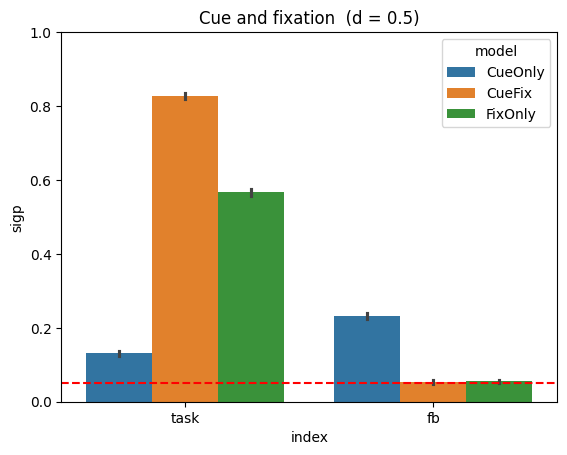

In [20]:
sns.barplot(data=all_results['CueFix'] , x='index', y='sigp', hue='model')
plt.title(f'Cue and fixation  (d = {delta})')
plt.ylim(0,1)
plt.axhline(0.05, color='red', linestyle='--')

Summary: When there is true activity for both cue and fixation, the CueOnly model has very low power to detect this, and also has inflated error rates for the feedback regressor.